# N2 · mini-CLIP: 让视觉懂语言 (对比学习)

> 配套 10.1-L2/L3 · 算图文相似度矩阵, 跑 InfoNCE (CLIP) 和 sigmoid (SigLIP) 损失,
> 改变配对噪声, 亲眼看「图文对齐越差, 损失越高」。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import numpy as np
import contrastive as ct
print('contrastive 就绪')

contrastive 就绪


## 1. 图文相似度矩阵 (L2): 配对正确时对角线最亮

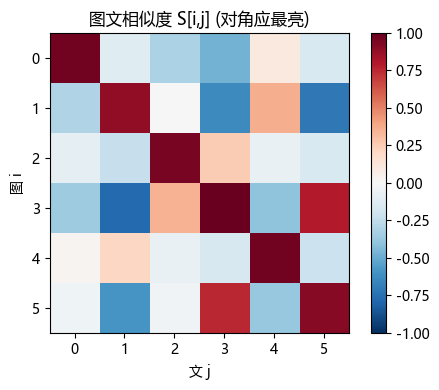

对角均值 0.944 >> 非对角均值 -0.114


In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
img_e, txt_e = ct.make_paired_embeddings(n=6, dim=8, noise=0.3, seed=1)
S = ct.similarity_matrix(img_e, txt_e)
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(S, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xlabel('文 j'); ax.set_ylabel('图 i'); ax.set_title('图文相似度 S[i,j] (对角应最亮)')
plt.colorbar(im); plt.tight_layout(); plt.show()
print(f"对角均值 {S.diagonal().mean():.3f} >> 非对角均值 {(S.sum()-S.trace())/(S.size-len(S)):.3f}")

## 2. InfoNCE (CLIP) vs Sigmoid (SigLIP) 损失 (L2/L3)

In [3]:
print(f"InfoNCE 损失: {ct.info_nce_loss(img_e, txt_e):.3f}")
print(f"Sigmoid 损失: {ct.sigmoid_loss(img_e, txt_e):.3f}")
print("\nInfoNCE: batch 内 softmax 归一化 (大 batch 友好); Sigmoid: 成对独立 (省 batch)。")

InfoNCE 损失: 0.031
Sigmoid 损失: 1.236

InfoNCE: batch 内 softmax 归一化 (大 batch 友好); Sigmoid: 成对独立 (省 batch)。


## 3. 对齐越差, 损失越高 (损失在度量「图文对齐质量」)

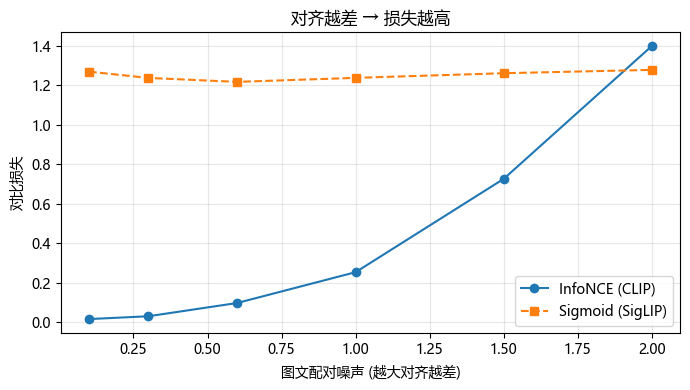

两种损失都随对齐变差单调上升 → 它们在直接优化「图文对齐」。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
noises = [0.1, 0.3, 0.6, 1.0, 1.5, 2.0]
nce = [ct.info_nce_loss(*ct.make_paired_embeddings(n=6, noise=nz, seed=1)) for nz in noises]
sig = [ct.sigmoid_loss(*ct.make_paired_embeddings(n=6, noise=nz, seed=1)) for nz in noises]
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(noises, nce, 'o-', label='InfoNCE (CLIP)')
ax.plot(noises, sig, 's--', label='Sigmoid (SigLIP)')
ax.set_xlabel('图文配对噪声 (越大对齐越差)'); ax.set_ylabel('对比损失')
ax.set_title('对齐越差 → 损失越高'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("两种损失都随对齐变差单调上升 → 它们在直接优化「图文对齐」。")

## 4. 反思 (10.1 收口)

你看清了 VLM 视觉塔「懂语言」的来源: **对比学习把配对图文拉近**。带走:
- ViT (N1) 把图变 token; 对比学习 (N2) 让这些 token 和语言对齐。
- InfoNCE 依赖大 batch (负样本); SigLIP 用成对 sigmoid 摆脱它 → 开源 VLM 默认。
- 训好的视觉塔输出「懂语言的视觉 token」, 接上 LLM 就成 VLM。

> 交棒 10.2: 视觉塔和接口都备好了 —— **视觉 token 到底怎么接进 LLM?**
> 下一专题 `vl-fusion-architectures`: cross-attention vs 投影 vs early-fusion 的决策树。